# KAN vs MLP Comparasion

In [2]:
import numpy as np

SEED = 42
np.random.default_rng(seed=SEED)

Generator(PCG64) at 0x1FBBA31ECE0

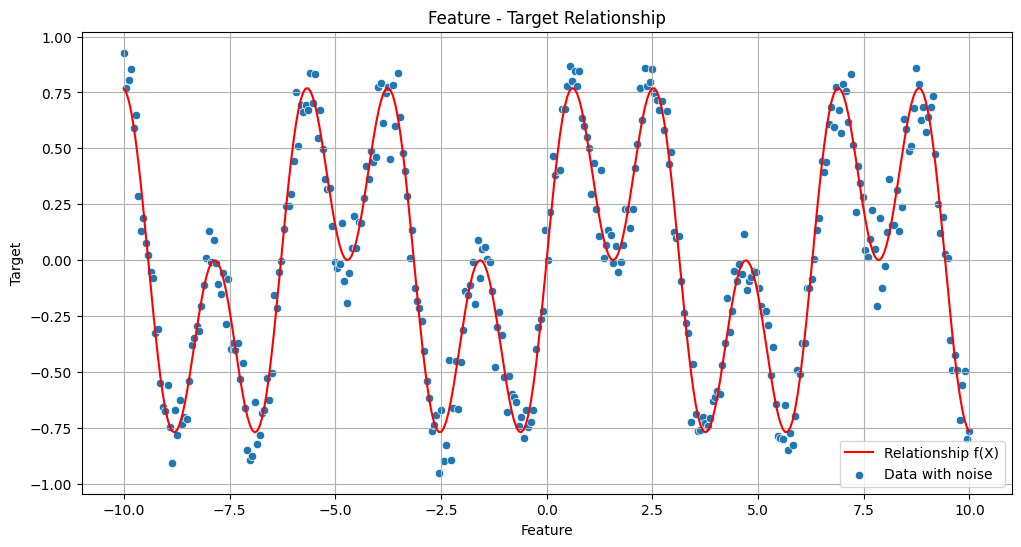

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

n = 350
range = (-10, 10)

X = np.linspace(range[0], range[1], n)
y_vis = np.sin(2*X)*np.cos(X)
y = y_vis + np.random.normal(0,0.1,X.shape)

plt.figure(figsize=(12,6))
plt.xlabel('Feature')
plt.ylabel('Target')
plt.grid()
plt.title('Feature - Target Relationship')
sns.lineplot(x=X,y=y_vis, color='red', label='Relationship f(X)')
sns.scatterplot(x=X, y=y, label='Data with noise')
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

split = 0.4

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split, random_state=SEED)

# Scale data using z-score standardization
X_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train.reshape(-1,1))
y_train = y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()

X_test = X_scaler.transform(X_test.reshape(-1,1))
y_test = y_scaler.transform(y_test.reshape(-1,1)).flatten()

# Check range coverage
print('Test data range: ', X_test.min(), X_test.max())
print('Train data range: ',X_train.min(), X_train.max())

Test data range:  -1.7315055285468346 1.7034649531857524
Train data range:  -1.7615490021479945 1.7335084267869119


In [5]:
from sklearn.metrics import mean_squared_error
from src.mlp import Network, ActivationLayer, FullyConnectedLayer
from src.utils import relu, relu_prime, mse, mse_prime
import optuna

n_trials = 50

# Network architecture definition

def make_mlp(layers):
    mlp = Network(mse, mse_prime, verbose=False)
    for layer in layers:
        mlp.add(layer)
    return mlp

layers = [
    FullyConnectedLayer(1, 128),
    ActivationLayer(relu, relu_prime),
    FullyConnectedLayer(128, 64),
    ActivationLayer(relu, relu_prime),
    FullyConnectedLayer(64, 32),
    ActivationLayer(relu, relu_prime),
    FullyConnectedLayer(32, 16),
    ActivationLayer(relu, relu_prime),
    FullyConnectedLayer(16, 1)
]

def objective(trial: optuna.Trial):
    mlp=make_mlp(layers)

    mlp.fit(
        X_train, y_train,
        epoches =       trial.suggest_int('epoches', 200, 700, step=10),
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        batch_size =    trial.suggest_categorical('batch_size', [16,32,64,128])
    )
    pred = mlp.predict(X_test)
    pred = np.array([x[0,0] for x in pred])
    return mean_squared_error(pred, y_test)

study = optuna.create_study(study_name='MLP_opt',sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials)

[I 2025-10-28 17:40:23,805] A new study created in memory with name: MLP_opt
[I 2025-10-28 17:40:24,286] Trial 0 finished with value: 0.7453143074919778 and parameters: {'epoches': 390, 'learning_rate': 0.007969454818643935, 'batch_size': 16}. Best is trial 0 with value: 0.7453143074919778.
[I 2025-10-28 17:40:26,282] Trial 1 finished with value: 0.7069401097511542 and parameters: {'epoches': 220, 'learning_rate': 0.005399484409787433, 'batch_size': 128}. Best is trial 1 with value: 0.7069401097511542.
[I 2025-10-28 17:40:32,217] Trial 2 finished with value: 0.7001889590814587 and parameters: {'epoches': 620, 'learning_rate': 0.00026587543983272726, 'batch_size': 128}. Best is trial 2 with value: 0.7001889590814587.
[I 2025-10-28 17:40:32,825] Trial 3 finished with value: 0.6955662956543412 and parameters: {'epoches': 420, 'learning_rate': 0.0003823475224675188, 'batch_size': 16}. Best is trial 3 with value: 0.6955662956543412.
[I 2025-10-28 17:40:34,943] Trial 4 finished with value: 0

{'epoches': 480, 'learning_rate': 0.0029481506835265206, 'batch_size': 16}


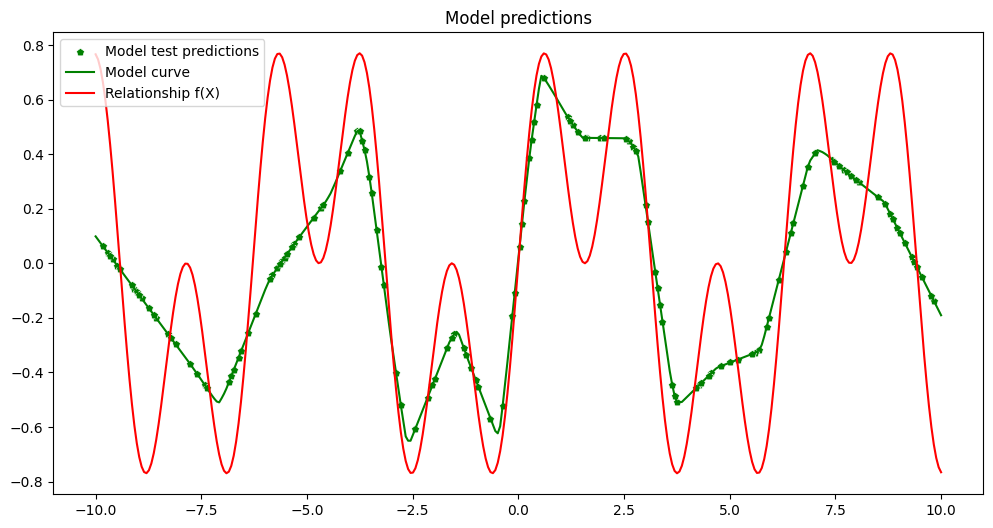

In [6]:
# Predict value and unwrap predictions to numpy array
print(study.best_params)
mlp=make_mlp(layers)
mlp.fit(X_train, y_train, **study.best_params)

vis = mlp.predict(X_scaler.transform(X.reshape(-1,1)).flatten())
pred = mlp.predict(X_test)
vis = np.array([x[0,0] for x in vis])
pred = np.array([x[0,0] for x in pred])

# Invert scaling
X_test_vis = X_scaler.inverse_transform(X_test).flatten()
vis = y_scaler.inverse_transform(vis.reshape(-1,1)).flatten()
pred = y_scaler.inverse_transform(pred.reshape(-1,1)).flatten()

# Plot
plt.figure(figsize=(12,6))
plt.title('Model predictions')
sns.scatterplot(x=X_test_vis, y=pred, color='green', marker='p', label='Model test predictions')
sns.lineplot(x=X, y=vis, color='green', label='Model curve')
sns.lineplot(x=X,y=y_vis, color='red', label='Relationship f(X)')
plt.show()

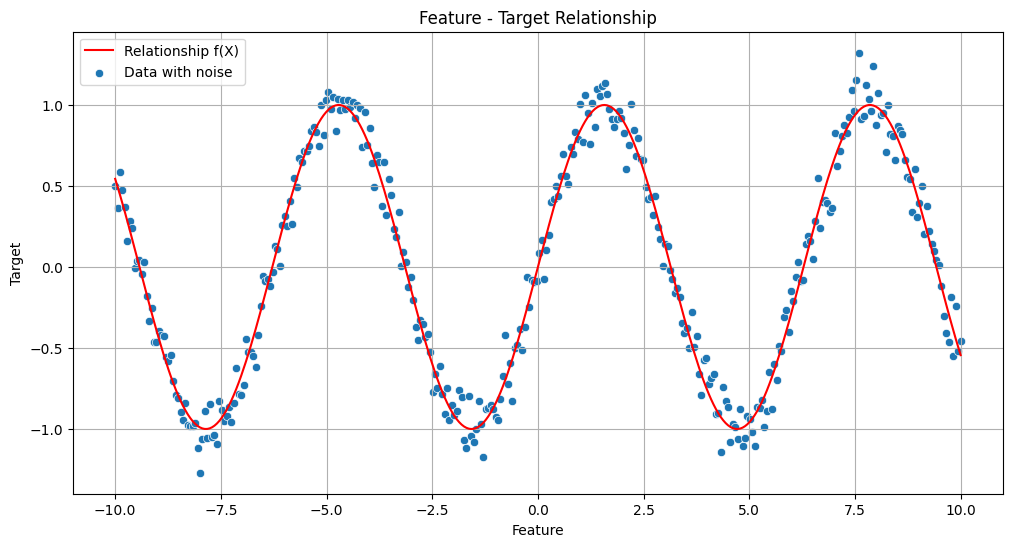

In [9]:
def simulate_data(f, n, range):
    X = np.linspace(range[0], range[1], n)
    
    y_vis = f(X)
    
    y = y_vis + np.random.normal(0,0.1,X.shape)

    plt.figure(figsize=(12,6))
    plt.xlabel('Feature')
    plt.ylabel('Target')
    plt.grid()
    plt.title('Feature - Target Relationship')
    sns.lineplot(x=X,y=y_vis, color='red', label='Relationship f(X)')
    sns.scatterplot(x=X, y=y, label='Data with noise')
    plt.show()

simulate_data(
    lambda X: np.sin(X),
    n=350,
    range=(-10,10)
)

In [ ]:
import pandas as pd

sim_data = pd.read_csv('./sim_data/sim_run_2025-11-10_18-38-29')